Atividade 2 -- Planejamento

# Descrição do problema:

Uma empresa deseja comparar a durabilidade de dois tipos de solado, A e B. Foram selecionados 10 garotos, e cada um utilizou simultaneamente uma sola do tipo A em um pé e uma sola do tipo B no outro pé. Após um período de uso, mediu-se o desgaste de cada sola. Os dados estão no apêndice.

# Questões:

Construa diferentes gráficos para representar os dados. Apresente medidas descritivas das diferenças. Analise os dados. Adicione o intervalo de confiança de 95% para a média das diferenças. Interprete os resultados no contexto do problema. Discuta se o uso de dados pareados foi adequado neste experimento. Compare com a análise que seria feita se os dados fossem considerados independentes.

# Métodos usados

Foram utilizados gráficos exploratórios para visualizar o comportamento dos dados, medidas descritivas das diferenças entre os pares, um teste t e um intervalo de confiança de 95% para a média das diferenças.

(Os dados e códigos usados estão no apêndice.)

# Resultados

### Gráficos:

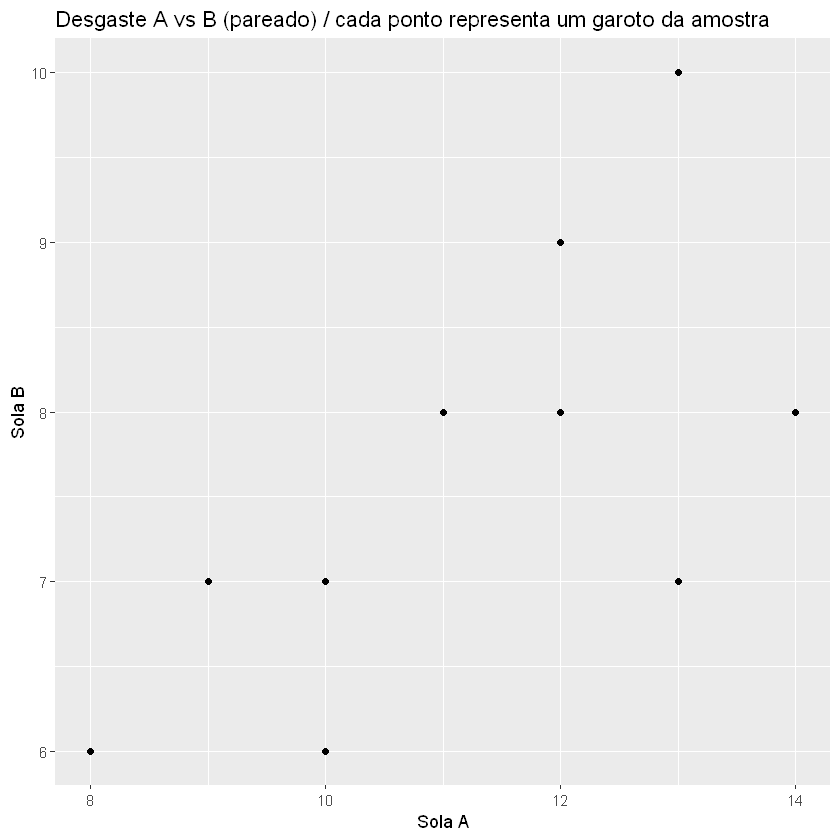
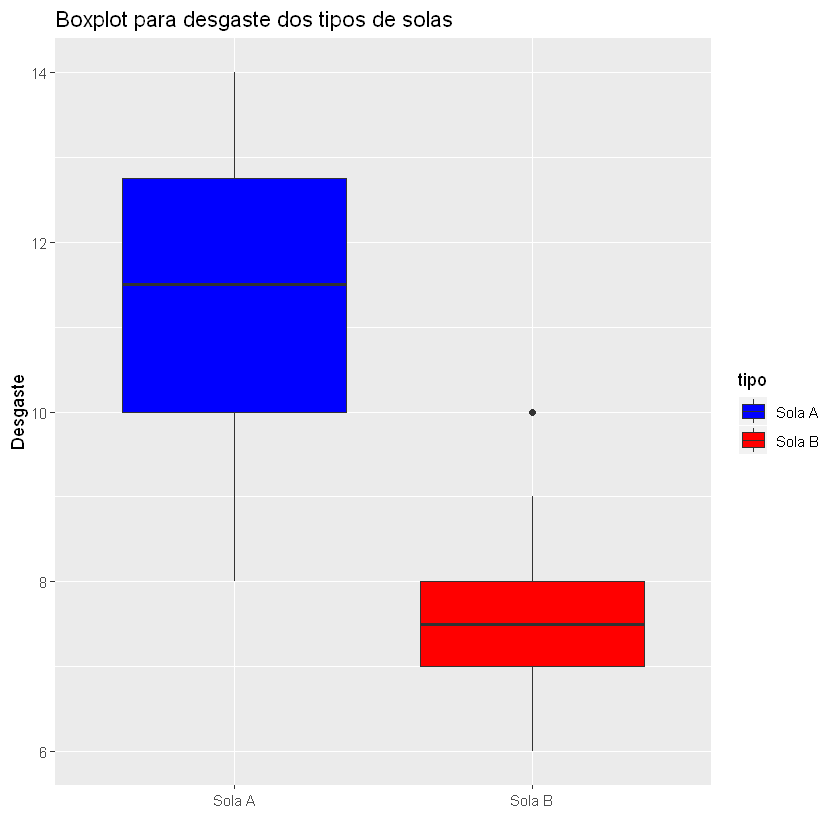
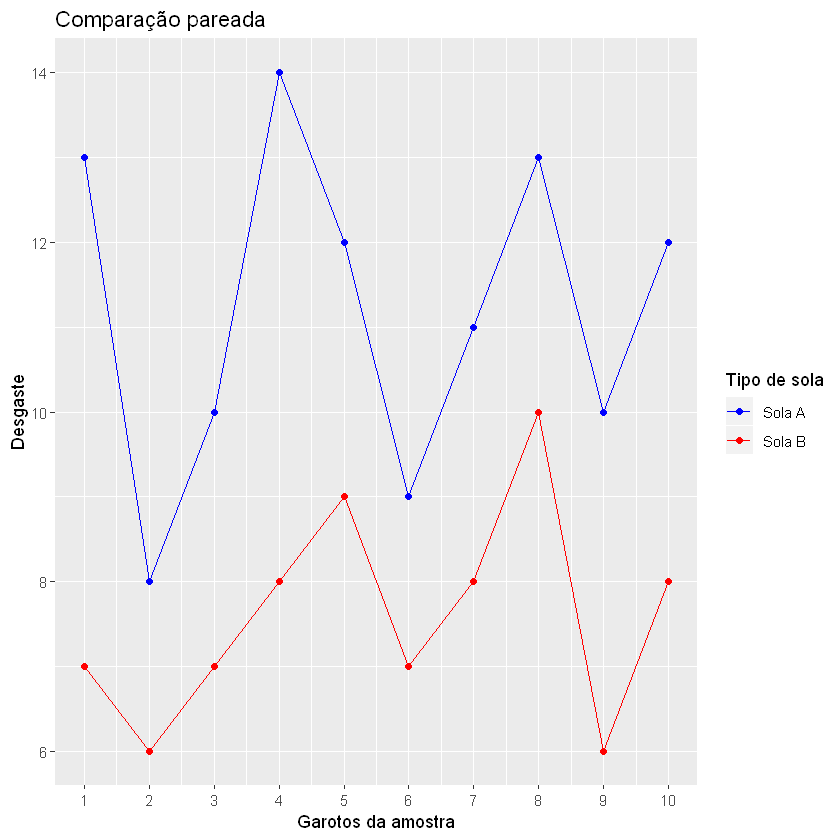

Foram construídos gráficos para visualizar os dados da amostra sobre desgastes.

Os gráficos indicam de forma consistente que o desgaste da sola B é inferior ao da sola A para a maioria dos indivíduos. Em particular, o gráfico de comparação pareada mostra que essa diferença ocorre em todas as unidades observadas.

### Medidas Descritivas das diferenças

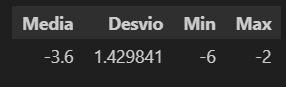

A média das diferenças (B − A) foi de -3.6, indicando que, em média o desgaste da sola B é menor do que o da sola A. 

O desvio padrão das diferenças foi de aproximadamente 1.43, sugerindo uma variabilidade moderada entre os indivíduos. 

Além disso, os valores da diferença variaram de -6 a -2. Isso mostra que, para todas unidades observadas, a sola B apresentou menor desgaste do que a sola A.

### Análise

In [28]:
resultado_teste_t_diferenca


	One Sample t-test

data:  diferenca
t = -7.9619, df = 9, p-value = 2.3e-05
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 -4.622846 -2.577154
sample estimates:
mean of x 
     -3.6 


Usando a estatística $t = \frac{\bar{D}}{(S_D / \sqrt{n})}$, o intervalo de confiança de 95% para a média das diferenças é [-4.62, -2.57].

### Interpretação:
Com esses dados, há evidências estatísticas de que a sola B é mais durável que a sola A, pois valor-p = ${2.3}*10^{-5}$, e o intervalo de confiança de 95% para a média das diferenças (B-A) é [-4.62, -2.57], contém apenas valores negativos.

### O uso de dados pareados foi adequado?

Vamos ver a saída de um teste t feito supondo que os dados são independentes.

In [27]:
resultado_teste_Como_se_fossem_independentes


	Welch Two Sample t-test

data:  desgaste_B and desgaste_A
t = -4.9295, df = 15.517, p-value = 0.0001647
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -5.152084 -2.047916
sample estimates:
mean of x mean of y 
      7.6      11.2 


Com essa saída, podemos perceber que a conclusão não mudou nesse caso, porém o valor-p aumentou e o intervalo de confiança ficou maior, indicando um poder menor do teste/precisão menor da estimativa. 

Então sim, o uso de dados pareados é de fato adequado por controlar a variabilidade das unidades experimentais.

# Apêndice

In [1]:
#digitando dados
desgaste_A <- c(13, 8, 10, 14, 12, 9, 11, 13, 10, 12)
desgaste_B <- c(7, 6, 7, 8, 9, 7, 8, 10, 6, 8)
diferenca <- desgaste_B - desgaste_A

dados <- data.frame(
  x = 1:length(desgaste_A),
  A = desgaste_A,
  B = desgaste_B,
  D = diferenca
)

In [3]:
# códigos para gráficos:
library(ggplot2)
dispersao <- ggplot(dados, aes(x = A, y = B)) +
  geom_point() +
  labs(
    title = "Desgaste A vs B (pareado) / cada ponto representa um garoto da amostra",
    x = "Sola A",
    y = "Sola B"
  )

In [4]:
dados_para_boxplot <- data.frame(
  desgaste = c(desgaste_A, desgaste_B),
  tipo = factor(rep(c("Sola A", "Sola B"), each = length(desgaste_A)))
)

bp <- ggplot(dados_para_boxplot, aes(x = tipo, y = desgaste, fill = tipo)) +
  geom_boxplot() +
  scale_fill_manual(values = c("blue", "red")) +
  labs(
    title = "Boxplot para desgaste dos tipos de solas",
    x = "",
    y = "Desgaste"
  )

In [22]:
comparacao <- ggplot(dados) +
  scale_color_manual(values = c("Sola A" = "blue", "Sola B" = "red")) +
  geom_line(aes(x, A, color="Sola A")) +
  geom_point(aes(x, A, color="Sola A")) +
  geom_line(aes(x, B, color="Sola B")) +
  geom_point(aes(x, B, color="Sola B")) +
  scale_x_continuous(breaks = 1:10) +
  labs(title="Comparação pareada",
       x="Garotos da amostra",
       y="Desgaste",
       color = "Tipo de sola")

In [24]:
# Medidas Descritivas e Analise de dados
medidas_descritivas_da_diferenca <- data.frame(
  Media = mean(diferenca),
  Desvio = sd(diferenca),
  Min = min(diferenca),
  Max = max(diferenca)
)

In [25]:
# Intervalo de Confiança
resultado_teste_t_diferenca <- t.test(diferenca, conf.level = 0.95)

In [26]:
#Teste caso os dados não são pareados
resultado_teste_Como_se_fossem_independentes <- t.test(desgaste_B,desgaste_A, paired = FALSE)